# OPM-MEG Tutorials in OSL: Source Localisation

### Note: data collected at Oxford OPM Lab December 2024

### Cerca Magnetics Neuro-1, 64-sensor QZFM OPM System

<img src="20250107_12_27_06_01.jpg" style="width:20%;">

## In this tutorial we will source localise the alpha-beta spectral changes during movement we found at the sensor-level using MNE's LCMV beamformer. However unlike MNE's typical source localisation pipeline, here we use the volumetric grid generated by osl-ephys' RHINO

In [ ]:
# We start by importing the relevant packages
import osl_ephys
import numpy as np
import mne
import glob
import yaml
import os
import matplotlib.pyplot as plt

# Set global font to Open Sans
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12  # Adjust font size as desired

%matplotlib inline


Using matplotlib as 2D backend.


## Specify Subject and subjects_dir

In [ ]:
subject      = '001'
ses          = '001'
task         = 'fourMotor'
run          = '001'

data_dir = os.path.join(os.getcwd(),'study-FourMotorOPM')

subjects_dir = os.path.join(
    data_dir, 'BIDS', 'derivatives', 'coreg'
)
os.makedirs(subjects_dir, exist_ok=True)


## Load in the Clean Data (after pre-processing)

In [3]:
output_dir = os.path.join(data_dir,
    'BIDS', 'derivatives', 'preprocessing',
    f'sub-{subject}', f'ses-{ses}', 'meg'
)

output_file = f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_clean.fif'

filename = os.path.join(output_dir, output_file)

clean = mne.io.read_raw_fif(filename, preload=True)

Opening raw data file /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif...


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77875/3588266154.py:10: RuntimeWarning: This filename (/Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  clean = mne.io.read_raw_fif(filename, preload=True)


    Read a total of 8 projection items:
        HFC: l=1 m=-1 (1 x 178) active
        HFC: l=1 m=0 (1 x 178) active
        HFC: l=1 m=1 (1 x 178) active
        HFC: l=2 m=-2 (1 x 178) active
        HFC: l=2 m=-1 (1 x 178) active
        HFC: l=2 m=0 (1 x 178) active
        HFC: l=2 m=1 (1 x 178) active
        HFC: l=2 m=2 (1 x 178) active
    Range : 0 ... 439756 =      0.000 ...  1465.853 secs
Ready.
Reading 0 ... 439756  =      0.000 ...  1465.853 secs...


## Band-Pass Filter from 8-30Hz - this covers mu and beta-band

In [4]:
# Use Butterworth IIR filter instead of FIR
iir_params = dict(order=4, ftype='butter')
clean.filter(l_freq=8.0, h_freq=30.0, method='iir', iir_params=iir_params)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 30.00 Hz: -6.02, -6.02 dB



<Raw | sub-001_ses-001_task-fourMotor_run-001_clean.fif, 192 x 439757 (1465.9 s), ~644.9 MiB, data loaded>

## Split the pre-processed data into epochs based on the embdeeded triggers

#### Note, we generated the events structure in tutorial 01

In [5]:
# Load events from .npy file saved from tutorial 01
events_file = os.path.join(
    data_dir, 'BIDS', 'derivatives', 'event',
    f'sub-{subject}', f'ses-{ses}', 'meg',
    f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_events.npy'
)

events = np.load(events_file)

event_id = {'left_arm': 1, 'left_leg': 2, 'right_arm': 3, 'right_leg': 4}
epochs = mne.Epochs(clean, events, event_id = event_id, tmin=-3, tmax=7,preload=True,event_repeated='drop')

# Now Split into Left and Right Trials
left  = epochs['left_arm','left_leg']
right = epochs['right_arm','right_leg']


Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
181 matching events found
Setting baseline interval to [-3.0, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 8)
8 projection items activated
Using data from preloaded Raw for 181 events and 3001 original time points ...
6 bad epochs dropped


#### Specify the time windows:
- Left Arm/Leg      +1 to +4 seconds
- Right Arm/Leg     +1 to +4 seconds
- Baseline          -3 to +3 seconds

In [6]:
# Now specify the correct time-windows
left      =  left.copy().crop(tmin = 1, tmax=4)
right     =  right.copy().crop(tmin=1, tmax=4)
baseline  =  epochs.copy().crop(tmin=-3, tmax=0)

## Quantify Covariance

#### First we compute covariance matrix across ALL time-points to compute a common filter, then condition specific covariance matrices are generated.

#### We can see the rank is automatically estimated at 168 (reduction due to HFC + ICA component removal)

    Created an SSP operator (subspace dimension = 8)
    Setting small MAG eigenvalues to zero (without PCA)
Reducing data rank from 178 -> 170
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 525175
[done]
    Created an SSP operator (subspace dimension = 8)
    Setting small MAG eigenvalues to zero (without PCA)
Reducing data rank from 178 -> 170
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 77486
[done]
    Created an SSP operator (subspace dimension = 8)
    Setting small MAG eigenvalues to zero (without PCA)
Reducing data rank from 178 -> 170
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 80189
[done]
    Created an SSP operator (subspace dimension = 8)
    Setting small MAG eigenvalues to zero (without PCA)
Reducing data rank from 178 -> 170
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 157675
[done]
Computing rank from covariance with rank=None
    Using tolerance 3e-13 (2.2e-16 eps * 178 dim

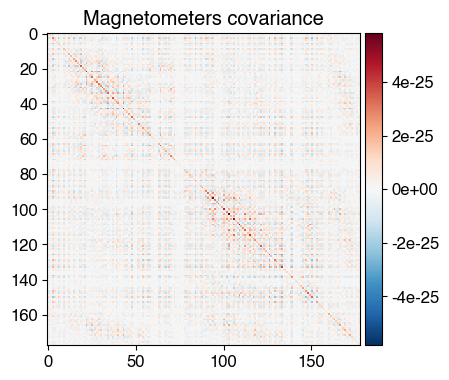

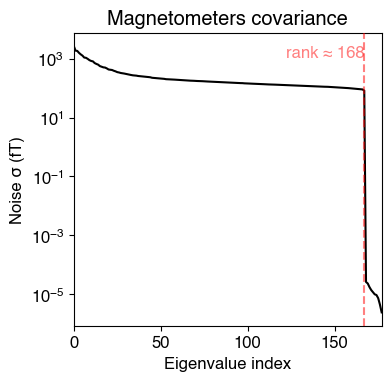

In [7]:
cov_all      = mne.compute_covariance(epochs, method='empirical')
cov_left     = mne.compute_covariance(left, method='empirical')
cov_right    = mne.compute_covariance(right, method='empirical')
cov_baseline = mne.compute_covariance(baseline, method='empirical')

# Plot the covariance matrix
fig_cov = mne.viz.plot_cov(cov_all, epochs.info)


## Read the Pre-Computed Forward Solution

#### This has been precomputed using the subject's MRI. The original MRI cannot be shared.

In [9]:
from mne import read_forward_solution

# load forward solution
fwd_fname = os.path.join(subjects_dir, subject, "rhino", "model-fwd.fif")
fwd = read_forward_solution(fwd_fname)

Reading forward solution from /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/coreg/sub-001/ses-001/meg/001/rhino/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (2863 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


## Beamform!

#### Here we use MNE's LCMV beamformer with 5% regularisation and covariance across all trials and times. 

#### Occasionally MNE estimates the rank incorrectly in OPM-MEG data due to multiple 'cliffs'. In these cases I use the code below to adjust the rank downwards.

In [10]:
rank = mne.compute_rank(clean)
rank['mag'] = rank['mag']-1
print(rank)

Computing rank from data with rank=None
Omitting 1200 of 439757 (0.27%) samples, retaining 438557 (99.73%) samples.
    Using tolerance 7.5e-11 (2.2e-16 eps * 178 dim * 1.9e+03  max singular value)
    Estimated rank (mag): 170
    MAG: rank 170 computed from 178 data channels with 8 projectors
{'mag': 169}


In [ ]:
from mne.beamformer import apply_lcmv_cov, make_lcmv

filters = make_lcmv(
    epochs.info,        # sensor info (channels, geometry, bads)
    fwd,                # forward model (lead field)
    cov_all,            # data covariance
    reg=0.05,           # covariance regularization
    noise_cov=None,     # no separate noise covariance
    pick_ori='max-power',  # orientation with max power
    rank=rank           # data rank
)


Computing rank from covariance with rank={'mag': 169}
Computing rank from covariance with rank={'mag': 169}
Making LCMV beamformer with rank {'mag': 169}
Computing inverse operator with 178 channels.
    178 out of 192 channels remain after picking
Selected 178 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 8)
Computing rank from covariance with rank={'mag': 169}
    Setting small MAG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 2863 sources
Filter computation complete


In [12]:
# Apply LCMV filter to each covariance matrix
stc_left     = apply_lcmv_cov(cov_left, filters)
stc_right    = apply_lcmv_cov(cov_right, filters)
stc_baseline = apply_lcmv_cov(cov_baseline, filters)

#### Make a sourcespace output directory in the BIDS-style derivatives folder


In [13]:
sourcespace_dir = os.path.join(
    data_dir,
    'BIDS',
    'derivatives',
    'sourcespace'
)

# Create coreg directory if it does not already exist
os.makedirs(sourcespace_dir, exist_ok=True)

### Below is a generic function to compute the difference between two source estimates (volumetric) using dB, followed by a spatial smoothing step

In [14]:
import numpy as np
from fsl import wrappers as fsl_wrappers
from osl_ephys.source_recon.rhino.utils import recon_timeseries2niftii

def compute_and_save_dB(
    baseline_stc,
    active_stc,
    subjects_dir,
    subject,
    output_file,
    spatial_resolution=8,
    reference_brain='mni',
    smooth_fwhm=5,
):
    """
    Compute dB difference between active and baseline source estimates,
    save as NIfTI, and apply spatial smoothing.

    Parameters
    ----------
    baseline_stc : mne.SourceEstimate
        Baseline source estimate.
    active_stc : mne.SourceEstimate
        Active condition source estimate.
    subjects_dir : str
        Path to FreeSurfer SUBJECTS_DIR.
    subject : str
        Subject identifier.
    output_file : str
        Output filename for the unsmoothed NIfTI (e.g., 'output.nii').
    spatial_resolution : float, optional
        Spatial resolution in mm. Default is 8.
    reference_brain : str, optional
        Reference brain space (e.g., 'mni'). Default is 'mni'.
    smooth_fwhm : float, optional
        Full-width at half-maximum (FWHM) for Gaussian smoothing in mm.
        Default is 5.

    Returns
    -------
    smoothed_file : str
        Path to the smoothed NIfTI file.
    """
    # Compute dB
    dB = 20 * np.log10(active_stc.data / baseline_stc.data)

    # Create new SourceEstimate with dB data
    stc_dB = active_stc.copy()
    stc_dB.data = dB

    # Save to NIfTI
    recon_timeseries2niftii(
        subjects_dir,
        subject,
        stc_dB.data,
        output_file,
        spatial_resolution=spatial_resolution,
        reference_brain=reference_brain,
        times=None,
    )

    # Generate smoothed filename
    smooth_file = output_file.replace(".nii", "_smooth.nii.gz")

    # Apply smoothing with FSL
    fsl_wrappers.fslmaths(output_file).s(smooth_fwhm).run(smooth_file)

    return smooth_file


## Plot Left Arm/Leg vs. Baseline in dB

In [15]:
smoothed_file = compute_and_save_dB(
    baseline_stc=stc_baseline,      # your baseline SourceEstimate
    active_stc=stc_left,            # your active SourceEstimate
    subjects_dir=subjects_dir,      # FreeSurfer SUBJECTS_DIR
    subject=subject,                # subject name/ID
    output_file=os.path.join(sourcespace_dir,f"left_diff-ses-{ses}_run-{run}.nii"),  # unsmoothed NIfTI filename
    spatial_resolution=8,           # mm resolution
    reference_brain="mni",          # reference space
    smooth_fwhm=5                   # Gaussian smoothing FWHM in mm
)

print("Smoothed NIfTI saved at:", smoothed_file)

Reading forward solution from /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/coreg/sub-001/ses-001/meg/001/rhino/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (2863 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
spatial_resolution = 8 mm
Smoothed NIfTI saved at: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/sourcespace/left_diff-ses-001_run-001_smooth.nii.gz


#### Plot the smoothed file using a glass-brain

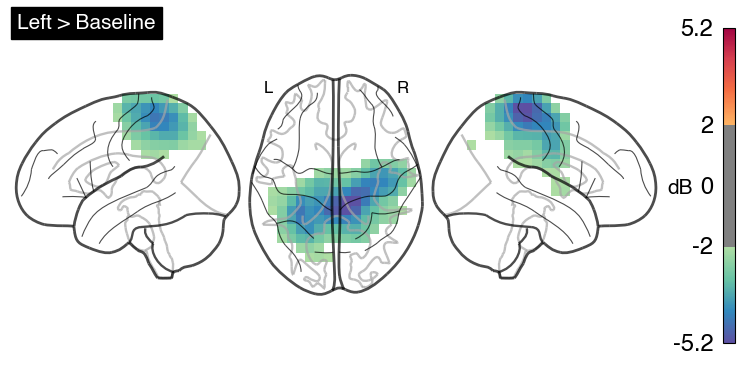

In [16]:
from nilearn import image, plotting

# Save the plot as a PNG image with 500 DPI
display = plotting.plot_glass_brain(smoothed_file, title='Left > Baseline',
                          threshold=2, colorbar=True, cmap="Spectral_r", plot_abs=False,
                          display_mode="lzr")

# Add the colorbar label using Matplotlib
cbar = display._cbar
cbar.set_label('dB', fontsize=15)
cbar.ax.tick_params(labelsize=17)
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_label_coords(-3.5, 0.46)
cbar.ax.yaxis.label.set_rotation(0)  # Set the label orientation to upright

# Show plot
plt.show()

## Plot Right Arm/Leg vs. Baseline

In [17]:
smoothed_file = compute_and_save_dB(
    baseline_stc=stc_baseline,      # your baseline SourceEstimate
    active_stc=stc_right,            # your active SourceEstimate
    subjects_dir=subjects_dir,      # FreeSurfer SUBJECTS_DIR
    subject=subject,                # subject name/ID
    output_file=os.path.join(sourcespace_dir,f"right_diff-ses-{ses}_run-{run}.nii"),  # unsmoothed NIfTI filename
    spatial_resolution=8,           # mm resolution
    reference_brain="mni",          # reference space
    smooth_fwhm=5                   # Gaussian smoothing FWHM in mm
)

print("Smoothed NIfTI saved at:", smoothed_file)

Reading forward solution from /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/coreg/sub-001/ses-001/meg/001/rhino/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (2863 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
spatial_resolution = 8 mm
Smoothed NIfTI saved at: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/sourcespace/right_diff-ses-001_run-001_smooth.nii.gz


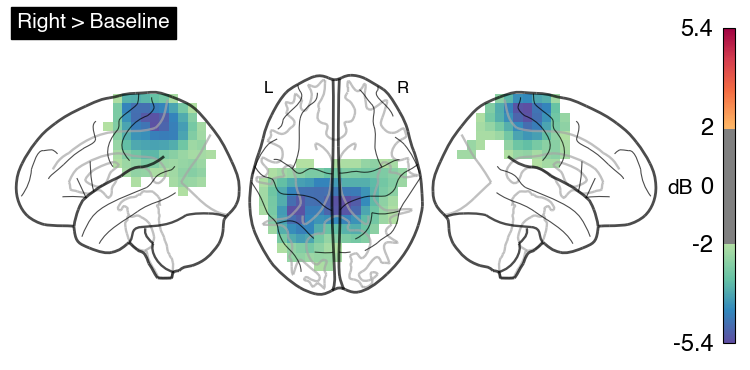

In [18]:
from nilearn import image, plotting

# Save the plot as a PNG image with 500 DPI
display = plotting.plot_glass_brain(smoothed_file, title='Right > Baseline',
                          threshold=2, colorbar=True, cmap="Spectral_r", plot_abs=False,
                          display_mode="lzr")

# Add the colorbar label using Matplotlib
cbar = display._cbar
cbar.set_label('dB', fontsize=15)
cbar.ax.tick_params(labelsize=17)
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_label_coords(-3.5, 0.46)
cbar.ax.yaxis.label.set_rotation(0)  # Set the label orientation to upright

# Show plot
plt.show()

## Plot Left vs. Right Movements

In [19]:
smoothed_file = compute_and_save_dB(
    baseline_stc=stc_right,      # your baseline SourceEstimate
    active_stc=stc_left,            # your active SourceEstimate
    subjects_dir=subjects_dir,      # FreeSurfer SUBJECTS_DIR
    subject=subject,                # subject name/ID
    output_file=os.path.join(sourcespace_dir,f"left_vs_right-ses-{ses}_run-{run}.nii"),  # unsmoothed NIfTI filename
    spatial_resolution=8,           # mm resolution
    reference_brain="mni",          # reference space
    smooth_fwhm=5                   # Gaussian smoothing FWHM in mm
)

print("Smoothed NIfTI saved at:", smoothed_file)

Reading forward solution from /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/coreg/sub-001/ses-001/meg/001/rhino/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (2863 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
spatial_resolution = 8 mm
Smoothed NIfTI saved at: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/sourcespace/left_vs_right-ses-001_run-001_smooth.nii.gz


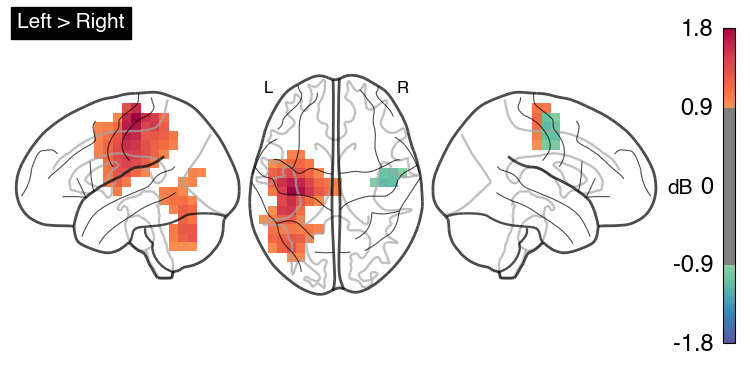

In [32]:
from nilearn import image, plotting

# Save the plot as a PNG image with 500 DPI
display = plotting.plot_glass_brain(smoothed_file, title='Left > Right',
                          threshold=0.9, colorbar=True, cmap="Spectral_r", plot_abs=False,
                          display_mode="lzr")

# Add the colorbar label using Matplotlib
cbar = display._cbar
cbar.set_label('dB', fontsize=15)
cbar.ax.tick_params(labelsize=17)
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_label_coords(-3.5, 0.46)
cbar.ax.yaxis.label.set_rotation(0)  # Set the label orientation to upright

# Show plot
plt.show()